Notebook 1: Dataset exploration and damage injection

This notebook loads the BLN600 corpus, selects sentences, measures real OCR errors, and injects synthetic
character-level damage at fixed levels (none, 1 word, 10%, 25%, 50%, 75% of a sentence with fact tokens).

**Inputs.** BLN600 (600 newspaper excerpts with human "gold" transcriptions and machine OCR text),
unpacked in `data/raw/BLN600/`, and the settings in `configs/config.yaml`.

**Outputs.** `data/processed/sentences.jsonl` (the sampled sentences),
`reports/pool_stats.csv`, `reports/calibration.json`, and the frozen damaged dataset
`data/processed/corrupted_v2.jsonl` with its hash in `runs/`.

Setup

In [1]:
import pandas as pd
# blnrepair is self developed for this project. implements the data pipeline, BERT repair, and LLM repair.
from blnrepair.data import ROOT, load_config, load_gold, load_metadata, excerpt_stats

pd.set_option("display.max_colwidth", 80)
config = load_config()
RAW = ROOT / config["paths"]["raw_dir"]
print("seed:", config["seed"])
print("raw data folder:", RAW.relative_to(ROOT))

seed: 42
raw data folder: data\raw\BLN600


Dataset

The gold transcriptions are our `Ground Truth/`. 
The machine OCR text in `OCR Text/` is used measure what real OCR errors look like, and then we calibrate our damage injection based on these measurements.

In [2]:
gold = load_gold(RAW) # normalization and cleaning is done here
meta = load_metadata(RAW)
stats = excerpt_stats(gold)
gold['3200797029']

['ROBBERY AT A BARONETS.',
 'EDWARD PRING, twenty-seven, carpenter, was brought up on remand at the Greenwich Police-court, charged with stealing jewellery to the value of £100, the property of Sir Robert Cunliffe, Bart., M.P., of 37 Lowndes street, Belgravia. Chief Inspector Phillips said there were a number of charges against the prisoner, all the robberies alleged being under similar circumstances. The prisoner was taken into custody, it appeared, on a charge of stealing a watch, and other articles, value £12, from the residence of Miss Keene, 8 Belgrave terrace, Lee. The prisoner called at the house and represented that he had been sent by the landlord to see to the blinds. He was given access to the bedrooms, and after he had gone a watch, two rings, and two lockets were missed. His statement of having been sent to the house was found to be false. The prisoner was ultimately arrested on this charge, and he was subsequently charged with the robbery from Sir R. Cunliffe’s upon infor

In [3]:
print("Words and paragraphs per excerpt:")
display(stats.describe().loc[["min", "25%", "50%", "75%", "max"]].round(0).astype(int))
print(f"Total words: {stats['words'].sum():,}")

Words and paragraphs per excerpt:


,paragraphs,words
min,1,53
25%,2,378
50%,4,468
75%,6,570
max,36,1288


Total words: 294,237


In [4]:
by_publication = meta["publication"].value_counts().rename("excerpts").to_frame()
by_decade = (meta["year"] // 10 * 10).value_counts().sort_index().rename("excerpts").to_frame()
display(by_publication)
display(by_decade.rename_axis("decade"))

,excerpts
publication,
Lloyd's Weekly Newspaper,340
The Illustrated Police News etc,212
Lloyd's Weekly London Newspaper,20
The Morning Chronicle,13
The Era,8
The Charter,6
Daily News,1


,excerpts
decade,
1830,17
1840,26
1850,72
1860,85
1870,94
1880,110
1890,196


Most excerpts come from 2 main publications related to crime. (To add to limitation)

Sentence pool

We cut the gold text into sentences using `pysbd` (spacy not great on historic excerpts), keep the sentences of 20 to 60 words, then find all **fact tokens** in each sentence. 

Fact token is a word a repair must get right. Example:
- a number, or any word with a digit (`23`, `5s.`, `6d.`), or a pound sign (`£100`);
- a capitalized word that is not the first word of the sentence (names, places, days).
  Not counted: `I`, `Mr`, `Mrs`, `Dr`, `St`, `The`, `Miss`, `Sir`, `Rev`, `Messrs`, and a word right after a token that ends in a colon.
  Days of the week, `Lord`, `Court` and `Police-court` still count.


In [5]:
import inspect
import pysbd

from blnrepair.data import build_sentences, split_sentences, make_pool, pool_funnel, pool_table
from blnrepair.facts import is_fact, mark_words
from blnrepair.plots import pool_bar_chart


In [6]:
# Return all sentences of all excerpts, with word count, length band and fact-token positions.
sentences = build_sentences(gold, config["sentence_pool"]["length_bands"])
print(f"Obtained {len(sentences):,} sentences")
sentences.head(2)

Obtained 13,487 sentences


,id,doc_id,text,n_words,band,fact_idx,n_facts
0,3200797029-000,3200797029,ROBBERY AT A BARONETS.,4,NaN,"[1, 2, 3]",3
1,3200797029-001,3200797029,"EDWARD PRING, twenty-seven, carpenter, was brought up on remand at the Green...",35,30-44,"[1, 11, 12, 21, 26, 27, 28, 29, 31, 32, 34]",11


Of the filtered sentences, count how many sentences remain, and how many excerpts they come from (at most 3 sentences are used per excerpt).

In [7]:
display(pool_funnel(sentences, config["sentence_pool"]))
pool, min_facts = make_pool(sentences, config["sentence_pool"])
capacity = pool.groupby("doc_id").size().clip(upper=3).sum()
print(f"Pool: {len(pool):,} sentences with at least {min_facts} fact tokens, from {pool['doc_id'].nunique()} excerpts.")

,sentences,excerpts
all sentences,13487,600
20 to 60 words,5989,598
... and at least 1 fact token,4263,597
... and at least 2 fact tokens,3123,592


Pool: 3,123 sentences with at least 2 fact tokens, from 592 excerpts.


Sentences outside 20 to 60 words are not used. Short sentences are often headlines, and long sentences are too low in number to be representative.

In [8]:
from blnrepair.data import length_coverage, long_examples

length_table = length_coverage(sentences)
display(length_table)
with pd.option_context("display.max_colwidth", 210):
    display(long_examples(sentences, 61, 80, seed=config["seed"]))
    display(long_examples(sentences, 81, 10**9, seed=config["seed"]))

,sentences,share of sentences,words,share of words
words per sentence,,,,
under 20,7146,0.530,73918,0.251
20-29,3114,0.231,75209,0.255
30-44,2131,0.158,75766,0.257
45-60,744,0.055,38109,0.129
61-80,241,0.018,16383,0.056
81 and more,111,0.008,15157,0.051


,n_words,start of sentence
id,,
3200810305-015,64,"The very day after the children had been cleansed and looked after in the workhouse the prisoner took them out, though he had no home or habitation, and that from that time forth and till lately he ha"
3200801630-002,63,"(Before Lord Coleridge and Mrs. Justice Mathew.) – In this case a rule had been granted for a certiorari to remove an indictment for libel preferred against George Francis Legg, a solicitor, on the pr"
3206313966-006,70,"A short time before his unhappy death he spoke to his landlord about being unable to pay his rent, some two or three shillings a week, when the landlord, much to his credit, instead of upbraiding the"


,n_words,start of sentence
id,,
3206269975-007,106,"The defendant gave evidence in support of this statement as to the extent of his means, and said. he had written a letter to Miss Charnell prior to the one given above, in which he told her he had com"
3200810284-011,93,"The evidence of the witness, as well as that of the mother, was taken through the medium of Mr. Karamelli, interpreter, and Mr. Morris remarking that the difficulty was to put the case clearly before"
3200801630-005,86,"A few weeks afterwards Mr. Legg, according to his affidavit, heard that Mr. Alexander had been accused of cheating a Mr. Wyndham of £550 at cards, at the Road Club, in January, 1885, and on the 18th o"


Pool counts by length band and number of fact tokens (`4+` means four or more fact tokens).

n_facts,2,3,4+,total,share
band,,,,,
20-29,430,295,622,1347,0.431
30-44,273,218,743,1234,0.395
45-60,95,75,372,542,0.174


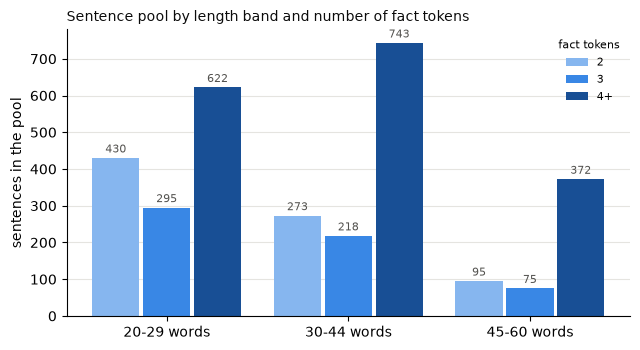

In [9]:
table = pool_table(pool)
display(table)
table.to_csv(ROOT / config["paths"]["reports_dir"] / "pool_stats.csv")
pool_bar_chart(table);

A few pool sentences with their fact tokens in [brackets].

In [10]:
examples = pool.sample(6, random_state=config["seed"])
marked = pd.DataFrame({
    "band": examples["band"],
    "sentence with fact tokens marked": [mark_words(t, i) for t, i in zip(examples["text"], examples["fact_idx"])],
}).set_index(examples["id"])
with pd.option_context("display.max_colwidth", 400):
    display(marked)

,band,sentence with fact tokens marked
id,,
3206328934-001,30-44,"On [Wednesday] [James] [Plato] attended at [Worship] street police-court, in answer to an adjourned summons charging him with having assaulted Mrs. [Sarah] [Pittendreigh] (well known from the [Tichborne] case and her many appearances before this court), with a felonious intent."
3206327966-003,30-44,"On the [29th] of [March,] at about eight o'clock in the evening, he was so engaged, and had put a number of watches into a box, when a man rushed in, seized the box, and ran away, the contents being worth about [100l.]"
3206275823-006,45-60,"The [1,799] deaths included [2] from smallpox, [45] from measles, [9] from scarlet fever, [24] from diphtheria, [61] from whooping-cough, [8] from enteric fever, [11] from diarrhea and dysentery, and not one typhus, ill-defined forms of continued fever, or cholera; thus, [160] deaths the corrected average weekly number."
3200809849-017,30-44,"Albert [Allen,] signalman at the [Victor] crossing, next to [Norton,] on the [Exeter] side, proved receiving the same notification, and receiving at eighteen minutes past one, [""Line] clear."" —Mr. [Kemp,] the [Norton] station-master, gave particulars as to when [Rice] went on duty."
3206325245-005,30-44,"Having breakfasted on [Tuesday] morning in his cell, he was taken to the gaol chapel, where the [Hon,] and Rev. [T.] [R.] [Grey,] rector of [Morpeth,] acting for the prison ordinary, who was unwell, read prayers to him."
3206258468-007,30-44,"The coroner, addressing the representatives of [Scotland-yard,] inquired whether there was any foundation for the report that had been circulated that deceased was implicated in the recent attempt to blow up [London-bridge.]"


The most frequent fact tokens in the pool (punctuation around a word removed)

In [11]:
from blnrepair.facts import top_fact_tokens

top_fact_tokens(pool, n=20)

,fact token,count,share
0,Monday,152,0.009
1,John,138,0.009
2,Saturday,137,0.009
3,Thursday,122,0.008
4,Friday,121,0.008
5,Wednesday,119,0.007
6,William,118,0.007
7,London,116,0.007
8,Tuesday,99,0.006
9,Police-court,98,0.006


Data split

Isolate **150 for testing** and **20 for development** (dev). Dev is only used to tune prompts and BERT configurations.

- The draw is random but fixed by seed set in config.yaml.
- Each length band gets a share of the sample equal to its share of the pool (proportional quotas), separately for test and dev.
- Dev sentences come only from excerpts that the test sample does not use, so no excerpt is in both sets. 

In [12]:
from blnrepair.data import band_quotas, draw_sample, sample_tables, save_sentences

sample = draw_sample(pool, config["sample"], config["sentence_pool"]["max_sentences_per_excerpt"], config["seed"])
by_band, spread = sample_tables(sample)
display(by_band)
display(spread.to_frame())

band,20-29,30-44,45-60,total
split,,,,
dev,9,8,3,20
test,65,59,26,150
total,74,67,29,170


,sample
sentences,170
excerpts,157
most sentences from one excerpt,3
excerpts with both test and dev sentences,0


The sample is written to `data/processed/sentences.jsonl`

In [13]:
save_sentences(sample, ROOT / config["paths"]["processed_dir"] / "sentences.jsonl")
with pd.option_context("display.max_colwidth", 110):
    display(sample.groupby("split").head(3)[["id", "split", "band", "n_words", "n_facts", "gold_text"]])

,id,split,band,n_words,n_facts,gold_text
0,3206211822-001,test,45-60,60,13,"On Thursday, Alfred Harris and Joseph Stanfield, a couple of lads in the employ of Messrs. Smith and Co., ..."
1,3200810644-004,test,30-44,33,2,"The prosecutor, who was not sober, was surrounded by several men, one of whom took his watch and pin, whil..."
2,3200809850-023,test,20-29,22,2,"He examined prisoner's hands at Kentish-town Police-station after her arrest, and found several superficia..."
150,3200812175-012,dev,30-44,36,4,"It was ascertained that he had hired a bicycle at Aberdeen, and had ridden from there to Perth, where, it ..."
151,3200812524-004,dev,30-44,30,3,"Police-constable Prime said he was at the Southend Railway-station the morning after the robbery, and alth..."
152,3206323884-017,dev,30-44,38,4,"Mr. William Hammond, farmer, of Brantham, spoke to hearing a quarrel between two persons near his house on..."


Calibrate error injection

We use real OCR errors in BLN600 to calibrate the damaging injection. We compare the machine OCR text with the gold text of other excerpts and count which characters get confused with which. Damaging pipeline uses this to make the synthetic damage look like real OCR errors.

In [14]:
from blnrepair.calibrate import sample_doc_ids, order_excerpts, load_pair, align_excerpts, coverage_totals, random_pairs

excluded = sample_doc_ids(ROOT / config["paths"]["processed_dir"] / "sentences.jsonl") # Get the doc_ids of the sample, to exclude them from calibration.
calib_order = order_excerpts(sorted(meta.index), excluded, config["seed"]) # Order the remaining excerpts for calibration.
print(f"{len(meta)} excerpts, {len(excluded)} used by the sample, {len(calib_order)} left for calibration")

600 excerpts, 157 used by the sample, 443 left for calibration


The same passage in the gold text and in the OCR text, for two excerpts. OCR words broken at a line end appear as `pro- perty`.

In [15]:
for doc_id in calib_order[:2]:
    gold_text, ocr_text = load_pair(RAW, doc_id)
    print(doc_id)
    print("  GOLD:", gold_text[:300])
    print("  OCR: ", ocr_text[:300])
    print()

3206222959
  GOLD: THE MURDER AT PORTSEA. On Monday, John Hughes was indicted before Mr. Justice Keating for the wilful murder of Maria Clements, at Portsea, on the 4th of June. It appeared from the evidence that the prisoner was a private soldier in the 26th regiment of foot, quartered at Cambridge barracks, at Ports
  OCR:  THE MURDER AT PORTSEA, On Monday, John Hughes was indibted before Mr. Justice Keating for the wilful murde- of, Maria ele- ments, at Portsea, on the 4th of June. It appeared from the evidence that the prisoner was a private soldier in the 26th regiment of foot, quartered at Cambridge barracks, at Po

3200811639
  GOLD: MURDER BY AN ITALIAN ORGAN GRINDER. PASQUALE PANOSSO, an Italian organ grinder, who was unable to speak English, was charged on Thursday morning at Wigan with the murder of a collier named Bernard Keenan, at Wigan. The prisoner and two other Italians were returning home the previous night when a num
  OCR:  MUNDER BY AN ITALIAN ORGAN e GRlNDER. e Sn

**Word alignment.** We line up the words of the two texts with `difflib`, comparing only the letters and digits of each word. Words that match are *equal*. Where 1 to 3 gold words stand against the same number of OCR words, we pair them one to one: these are the *erroneous word pairs*. All other gold words stay *unpaired* (a missing line, a word split in two, columns in the wrong order).

An excerpt is used only if at least 60% of its gold words are equal or paired.

In [16]:
import re

align_table, aligned = align_excerpts(RAW, calib_order, n=30, min_keep=20, min_coverage=0.60)
display(align_table)
first_30 = align_table.iloc[:30]
print(f"Excerpt CER: mean {first_30['cer'].mean():.3f}, median {first_30['cer'].median():.3f}")
totals, word_error_rate = coverage_totals(align_table)
print(f"Used {len(aligned)} excerpts. Gold words {totals['gold_words']:,}: equal {totals['equal']:,}, "
      f"paired {totals['paired']:,}, unpaired {totals['unpaired']:,}. Word error rate {word_error_rate:.3f}")
split_words = sum(len(re.findall(r"[A-Za-z]- [a-z]", load_pair(RAW, d)[1])) for d in aligned)
print(f"Words split at a line end in the OCR (like pro- perty), left as they are: {split_words}")

,cer,gold_words,equal,paired,unpaired,coverage,used
doc_id,,,,,,,
3206222959,0.035,724,651,32,41,0.943,True
3200811639,0.093,272,239,19,14,0.949,True
3206247550,0.050,569,483,52,34,0.940,True
3206240630,0.089,375,290,38,47,0.875,True
3200810647,0.180,111,87,13,11,0.901,True
3200810958,0.075,892,733,107,52,0.942,True
3200811428,0.120,599,379,95,125,0.791,True
3206314317,0.063,532,420,60,52,0.902,True
3206261127,0.059,402,331,43,28,0.930,True


Excerpt CER: mean 0.082, median 0.060
Used 29 excerpts. Gold words 13,839: equal 11,430, paired 1,148, unpaired 1,261. Word error rate 0.091
Words split at a line end in the OCR (like pro- perty), left as they are: 138


Checking out random pairs:

In [17]:
random_pairs(aligned, 15, config["seed"]).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
gold,on,drunk,Camberwell,number,boiler,mere,notes,January,ratepayers,back,He,He,Paddington,to,had
ocr,or,diunkr,Cambernwell,ntinber,blier,men,notee,Jammu:oy,ratcpayers,bhack,Ee,Ee,Paddlngton,regarNto,hab


**Character confusions.** We now look inside the erroneous word pairs. We use only the *clean* pairs (Tier A), where the gold and OCR word share at least half of their letters (`rapidfuzz` ratio of 50 or more). A pair with less in common is more likely an alignment mistake than an OCR error. We also leave out pairs whose lengths differ by 3 or more characters: *merged* pairs, where the OCR glued a neighbouring word on (`on` read as `downon`), and *split* pairs, where the OCR kept only part of the word (`superficial` read as `super`). These stay in Tier B.

For each clean pair we list the character edits from gold to OCR. Neighbouring edits are merged into one block, so `m` read as `rn` counts as one confusion. A block is a *substitution* (1 to 2 characters on each side), a *deletion* (the OCR lost the characters), an *insertion* (the OCR added characters) or *other* (a longer change).

In [18]:
from blnrepair.calibrate import char_blocks, tier_a, all_pairs, flagged_pairs, char_tables

pairs_a, pairs_b = tier_a(aligned, floor=50), all_pairs(aligned)
flags = flagged_pairs(aligned, floor=50)
for flag, pairs in flags.items():
    print(f"{flag}: {len(pairs)} pairs moved out of Tier A, for example:", ", ".join(f"{g} -> {o}" for g, o in pairs[:5]))
confusions, op_mix, deletion_rate = char_tables(aligned, pairs_a)
print(f"Clean pairs (Tier A): {len(pairs_a)} of {len(pairs_b)} erroneous word pairs")

merged: 13 pairs moved out of Tier A, for example: on -> downon, not -> does''not, across -> woundacross, persons -> persons.-The, act -> act.-Mr
split: 17 pairs moved out of Tier A, for example: children -> chil, Kennington-park -> Kenning, superficial -> super, about -> ot, prisoner's -> soner's
Clean pairs (Tier A): 976 of 1148 erroneous word pairs


The 15 most frequent confusions (`N/A` means the OCR lost the character). *Rate* is the count divided by how often the gold characters occur in all aligned gold words, so a frequent letter like `e` does not look important only because it is frequent.

In [19]:
confusions.head(15).assign(ocr=lambda d: d["ocr"].replace("", "N/A")).round(4)

,gold,ocr,count,rate
0,c,o,21,0.0155
1,h,b,19,0.0053
2,o,e,18,0.0044
3,s,e,18,0.0058
4,s,N/A,17,0.0055
5,n,N/A,17,0.0044
6,c,e,14,0.0103
7,a,s,12,0.0027
8,u,a,11,0.0081
9,e,o,11,0.0016


The mix of edit types, and the share of gold characters the OCR deleted.

In [20]:
display(pd.Series(op_mix, name="share of edit blocks").round(3).to_frame())
print(f"Deleted gold characters: {deletion_rate:.4f} of all characters in aligned words")

,share of edit blocks
substitution,0.626
deletion,0.110
insertion,0.239
other,0.024


Deleted gold characters: 0.0025 of all characters in aligned words


**Error per word.** For each erroneous word: edited characters divided by the length of the gold word (at most 1). This is the same idea as "share of characters altered" in our damage, which we set to 20 to 30%. Short words are shown separately, because one wrong letter in a 3-letter word is already 33%.

The clean pairs (Tier A) give the lower end of the range, because the least similar pairs are left out. All pairs (Tier B) give the upper end, because they also contain alignment mistakes.

In [21]:
from blnrepair.calibrate import per_word_error, per_word_table

per_word = per_word_error(pairs_a, pairs_b)
per_word_table(per_word)

n   mean  median     q1     q3  share_ge_0.40
pairs  words                                                  
tier_a min4    715  0.254   0.222  0.143  0.333          0.178
       all     976  0.308   0.279  0.182  0.400          0.259
tier_b min4    788  0.300   0.250  0.167  0.400          0.253
       all    1148  0.391   0.333  0.200  0.500          0.369

**Check length flags.** 

Tier A without the flags (ratio only) and with them. Little changes, and the top confusions are the same, so the confusion table is not driven by alignment mistakes.

In [22]:
from blnrepair.calibrate import before_after

with pd.option_context("display.max_colwidth", 80):
    display(before_after(aligned, floor=50))

,before (ratio only),"after (ratio, no merged/split)"
Tier A pairs,1006,976
top-5 confusions,"c>o 21, h>b 19, o>e 18, s>e 18, s>∅ 17","c>o 21, h>b 19, o>e 18, s>e 18, s>∅ 17"
edit mix: substitution,0.611,0.626
edit mix: deletion,0.108,0.110
edit mix: insertion,0.234,0.239
edit mix: other,0.047,0.024
deleted characters,0.0025,0.0025
"per-word error, Tier A, min4","median 0.240, mean 0.267, >=0.40 0.204","median 0.222, mean 0.254, >=0.40 0.178"
"per-word error, Tier A, all","median 0.286, mean 0.320, >=0.40 0.280","median 0.279, mean 0.308, >=0.40 0.259"


**Whole words lost.** How often the OCR drops 1 or 2 words that have matching words on both sides, per gold word. 

In [23]:
from blnrepair.calibrate import isolated_drop_rate

drop_rate = isolated_drop_rate(aligned)
print(f"Isolated word drops per gold word: {drop_rate:.4f}")

Isolated word drops per gold word: 0.0002


All results are saved to `reports/calibration.json`, used by damage pipeline

In [24]:
from blnrepair.calibrate import save_calibration

calibration = save_calibration(ROOT / config["paths"]["reports_dir"] / "calibration.json", config["seed"], align_table,
                               aligned, pairs_a, confusions, op_mix, deletion_rate, per_word, drop_rate, flags)
print("Saved:", ", ".join(calibration))

Saved: seed, excerpts_used, excerpts_dropped, cer_per_excerpt, coverage, word_error_rate_overall, pairs, op_mix, char_deletion_rate, confusions, per_word_error, isolated_word_drop_rate


Damage Pipeline

For each sentence we pick one **anchor** word among its fact tokens, with a fixed random draw. The damaged words form one block around the anchor, and the block grows with the level: 1 word, then 10%, 25%, 50% and 75% of the words. Level 0 is the clean sentence.

Each word gets one damage plan, made once from a seed built from the sentence id and the word position. A level only decides which words use their plan, so a damaged word looks the same at every level. The plan:

- about 10% of damaged words are dropped completely (a placeholder value), except the anchor word, which is never dropped, so every level damages at least one fact token;
- otherwise 20 to 30% of the word's letters and digits are altered; punctuation is never touched;
- each altered character is deleted (about 15% of the time, as in the calibration, at most 2 per word) or replaced;
- a replacement comes from the calibrated confusion table when that character has entries there (a capital letter uses the entry of its lowercase letter, written as a capital), otherwise from a short list of look-alike characters, otherwise from a random character of the same kind.

In [25]:
from blnrepair.corrupt import select_span, plan_word

pull calibration.json.

In [26]:
import json

from blnrepair.corrupt import settings, load_table, level_sizes

calibration = json.loads((ROOT / config["paths"]["reports_dir"] / "calibration.json").read_text(encoding="utf-8"))
corr = settings(config, calibration)
confusion_table = load_table(calibration)
print(f"Deletion share: {corr['p_deletion']}, intensity: {corr['intensity_low']} to {corr['intensity_high']}, "
      f"word drop: {corr['drop_prob']}, at most {corr['max_deletions']} deletions per word")
print("Damaged words per level for a 25-word sentence:", level_sizes(25))

Deletion share: 0.15, intensity: 0.2 to 0.3, word drop: 0.1, at most 2 deletions per word
Damaged words per level for a 25-word sentence: {'1w': 1, '10': 3, '25': 6, '50': 13, '75': 19}


One test sentence at all six levels. Damaged words are shown in `[[...]]`, a dropped word as `[[]]`.

In [27]:
from blnrepair.corrupt import corrupt_sentence, mark_damage

rows = [json.loads(line) for line in (ROOT / config["paths"]["processed_dir"] / "sentences.jsonl").read_text(encoding="utf-8").splitlines()]
example = rows[0]
levels = [corrupt_sentence(example, level, confusion_table, corr) for level in corr["levels"]]
print(example["id"], "| split:", example["split"], "| words:", example["n_words"], "| anchor:", levels[1]["gold_tokens"][levels[1]["anchor_idx"]])
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame({"level": [r["severity"] for r in levels], "k": [r["k"] for r in levels],
                          "damaged text": [mark_damage(r) for r in levels]}).set_index("level"))

3206211822-001 | split: test | words: 60 | anchor: Joseph


,k,damaged text
level,,
0,0,"On Thursday, Alfred Harris and Joseph Stanfield, a couple of lads in the employ of Messrs. Smith and Co., whip makers, of Beech street, Barbican, were charged, at the Guildhall police-court, with robbing their employers of goods to the value of nearly 100l. , and Joseph Taylor was charged with feloniously receiving the property knowing it to have been stolen."
1w,1,"On Thursday, Alfred Harris and Joseph Stanfield, a couple of lads in the employ of Messrs. Smith and Co., whip makers, of Beech street, Barbican, were charged, at the Guildhall police-court, with robbing their employers of goods to the value of nearly 100l. , and [[Jeseph]] Taylor was charged with feloniously receiving the property knowing it to have been stolen."
10,6,"On Thursday, Alfred Harris and Joseph Stanfield, a couple of lads in the employ of Messrs. Smith and Co., whip makers, of Beech street, Barbican, were charged, at the Guildhall police-court, with robbing their employers of goods to the value of nearly [[10l.]] [[]] [[nd]] [[Jeseph]] [[Tey1or]] [[wag]] charged with feloniously receiving the property knowing it to have been stolen."
25,15,"On Thursday, Alfred Harris and Joseph Stanfield, a couple of lads in the employ of Messrs. Smith and Co., whip makers, of Beech street, Barbican, were charged, at the Guildhall police-court, with robbing their employers of goods to [[bhe]] [[valne]] [[ot]] [[uear1y]] [[10l.]] [[]] [[nd]] [[Jeseph]] [[Tey1or]] [[wag]] [[clarge]] [[vith]] [[f1onieusly]] [[iecelving]] [[bhe]] property knowing it to have been stolen."
50,30,"On Thursday, Alfred Harris and Joseph Stanfield, a couple of lads in the employ of Messrs. Smith and Co., whip makers, of Beech street, Barbican, were charged, at the Guildhall [[poliee-ceurt,]] [[wth]] [[iobbIng]] [[]] [[empoyere]] [[]] [[goeds]] [[]] [[bhe]] [[valne]] [[ot]] [[uear1y]] [[10l.]] [[]] [[nd]] [[Jeseph]] [[Tey1or]] [[wag]] [[clarge]] [[vith]] [[f1onieusly]] [[iecelving]] [[bhe]] [[prepsrty]] [[koWing]] [[lt]] [[te]] [[hane]] [[beei]] [[ebolen.]]"
75,45,"On Thursday, Alfred Harris and Joseph Stanfield, a couple of lads in the employ of [[Mesars.]] [[]] [[]] [[C.,]] [[whii]] [[mekers,]] [[ot]] [[Beoch]] [[sbreet,]] [[Harbioan,]] [[weie]] [[hsrged,]] [[st]] [[tbe]] [[Guilcliall]] [[poliee-ceurt,]] [[wth]] [[iobbIng]] [[]] [[empoyere]] [[]] [[goeds]] [[]] [[bhe]] [[valne]] [[ot]] [[uear1y]] [[10l.]] [[]] [[nd]] [[Jeseph]] [[Tey1or]] [[wag]] [[clarge]] [[vith]] [[f1onieusly]] [[iecelving]] [[bhe]] [[prepsrty]] [[koWing]] [[lt]] [[te]] [[hane]] [[beei]] [[ebolen.]]"


What the damage looks like over all 170 sentences. We use level 75, which holds every damaged word, because smaller blocks lie inside it. *Intensity* is the share of a word's letters and digits that were altered. The second table gives the character error rate of the whole damaged sentence against the gold sentence at each level, which can be compared with the real OCR error rate (about 0.07 for a whole excerpt).

In [28]:
from blnrepair.corrupt import corruption_stats, cer_by_level

stats = corruption_stats([corrupt_sentence(r, "75", confusion_table, corr) for r in rows])
stats["cer_by_level"] = cer_by_level(rows, confusion_table, corr)
(ROOT / config["paths"]["reports_dir"] / "corruption_stats.json").write_text(json.dumps(stats, indent=1), encoding="utf-8")
display(pd.json_normalize({k: v for k, v in stats.items() if k != "cer_by_level"}).T.rename(columns={0: "value"}).round(3))
print("Character error rate of the damaged sentence against the gold sentence, by level (170 sentences):")
pd.DataFrame(stats["cer_by_level"]).T.rename_axis("level").round(3)

,value
damaged_words,4263.000
share_dropped,0.099
deletion_share_of_altered_chars,0.146
digit_words,87.000
no_alnum_tokens,7.000
substitution_source_share.table,0.857
substitution_source_share.table_casefold,0.036
substitution_source_share.fallback_map,0.049
substitution_source_share.fallback_random,0.058
mean_intensity_by_length.1-3,0.451


Character error rate of the damaged sentence against the gold sentence, by level (170 sentences):


,mean,median,q1,q3
level,,,,
0,0.000,0.000,0.000,0.000
1w,0.010,0.009,0.006,0.013
10,0.032,0.027,0.021,0.038
25,0.079,0.073,0.063,0.091
50,0.155,0.149,0.131,0.174
75,0.231,0.226,0.202,0.257


In [29]:
from blnrepair.corrupt import review_examples, review_table

review = review_table(review_examples(rows, confusion_table, corr))
with pd.option_context("display.max_colwidth", None, "display.width", 250):
    display(review)

,level,band,k,fact words in span,gold sentence,damaged (marked)
id,,,,,,
3200811564-027,1w,20-29,1,Sutton.,"He said that, as arranged on Good Friday, he sent her his address, but he could not see that this enticed her from Sutton.","He said that, as arranged on Good Friday, he sent her his address, but he could not see that this enticed her from [[Suttan.]]"
3200812378-002,1w,30-44,1,Baroness,"The Baroness de Rahden, the heroine of the drama, was a circus rider of the haute ecole, Lieutenant de Kastenkjold made himself conspicuous by his admiration of the baroness, who allowed him to follow her from town to town.","The [[Baonese]] de Rahden, the heroine of the drama, was a circus rider of the haute ecole, Lieutenant de Kastenkjold made himself conspicuous by his admiration of the baroness, who allowed him to follow her from town to town."
3206222380-003,1w,45-60,1,Jabez,"She had been living in the service of the Rev. Jabez Tunnicliffe, who is the officiating minister at the Burmantofts cemetery, Leeds, but left suddenly on Sunday night week, and went to reside with Mrs. Waite, of Napier-street, Burmantofts, who is the married daughter of Mr. Tunnicliffe.","She had been living in the service of the Rev. [[Jahez]] Tunnicliffe, who is the officiating minister at the Burmantofts cemetery, Leeds, but left suddenly on Sunday night week, and went to reside with Mrs. Waite, of Napier-street, Burmantofts, who is the married daughter of Mr. Tunnicliffe."
3206327837-020,1w,20-29,1,Lawrence,"This was an indictment for conspiracy, the prosecutor being Mr. Lawrence Levy, formerly an attorney, and the defendants being a firm of solicitors.","This was an indictment for conspiracy, the prosecutor being Mr. [[Lawenc]] Levy, formerly an attorney, and the defendants being a firm of solicitors."
3206329007-012,10,30-44,3,Wright,"He also stated he had seen Wright put three nuts into the cog wheel on three consecutive mornings, while Wright on the other hand accused him of being the guilty party.","He also stated he had seen Wright put three nuts into the cog wheel on three consecutive mornings, [[whlle]] [[Viight]] [[en]] the other hand accused him of being the guilty party."
3206203053-011,10,45-60,5,"Maria, Froggatt","Anna Maria Froggatt deposed that she first made prisoner's acquaintance at Preston, in 1847, when he induced her to leave her home, and accompany him to Gretna-hall, in Scotland, where they were married, according to the ceremony observed there, and pronounced by the Rev. Mr. Linton, the priest, to be legally man and wife.","[[Snna]] [[Naria]] [[Froggst]] [[clepoed]] [[tbat]] she first made prisoner's acquaintance at Preston, in 1847, when he induced her to leave her home, and accompany him to Gretna-hall, in Scotland, where they were married, according to the ceremony observed there, and pronounced by the Rev. Mr. Linton, the priest, to be legally man and wife."
3206232665-017,10,20-29,2,Wallace,"The impression was that the child had been taken away by the Wallace’s, Mrs. Wallace being a very strange woman.","The impression was that the child had been taken away by the Wallace’s, [[Mss.]] [[Wellsce]] being a very strange woman."
3200810696-001,10,30-44,4,"Thomas, Hurd,","A POWERFULLY-BUILT man, named Thomas Hurd, a commission agent, who refused his address, was charged, at Marylebone Police-court, on Saturday, with being concerned, with others, in obtaining 10s, by means of a trick from Frank Bliss, a medical student, of 29, Paddington-green.","A POWERFULLY-BUILT man, [[iamed]] [[Bhomas]] [[Husd,]] [[e]] commission agent, who refused his address, was charged, at Marylebone Police-court, on Saturday, with being concerned, with others, in obtaining 10s, by means of a trick from Frank Bliss, a medical student, of 29, Paddington-green."
3206223815-014,25,45-60,14,"Police-constable, Abbott","He had seen a quantity of sovereigns in the possession of Police-constable Abbott that morning, and he could swear that some of them were his prope

Freeze

Damaged dataset is written once and frozen, so that both repair methods later see exactly the same inputs. `data/processed/corrupted_v2.jsonl` has one row per sentence and level (170 sentences x 6 levels = 1,020 rows, in the order of `sentences.jsonl`, then level 0, 1w, 10, 25, 50, 75). 

`runs/corrupted_v2.sha256` holds the hash of the file
`runs/config_snapshot_v2.yaml` holds the version, seed, all damage settings, the hashes of the two input files and the package versions. 

In [30]:
from blnrepair.freeze import build_records, freeze, verify_freeze

records = build_records(rows, confusion_table, corr)
processed_dir, reports_dir, runs_dir = (ROOT / config["paths"][k] for k in ("processed_dir", "reports_dir", "runs_dir"))
status, digest = freeze(records, "v2", corr, processed_dir, reports_dir, runs_dir)
print(f"corrupted_v2.jsonl: {status}")

corrupted_v2.jsonl: unchanged


In [31]:
rebuilt = verify_freeze(rows, confusion_table, corr, "v2", processed_dir, runs_dir)
size = (processed_dir / "corrupted_v2.jsonl").stat().st_size
print(f"sha256: {rebuilt}")
print("The rebuilt hash equals the stored hash and the file on disk.")
print(f"Rows: {len(records):,}, file size: {size:,} bytes")
pd.crosstab(pd.Series([r["severity"] for r in records], name="level"),
            pd.Series([r["split"] for r in records], name="split"), margins=True).reindex(corr["levels"] + ["All"])

sha256: 5798336d99ff2a8ada306e0752bcd25298287d0bf9f0ad4b5fc0c6468a6b9eb9
The rebuilt hash equals the stored hash and the file on disk.
Rows: 1,020, file size: 2,319,195 bytes


split,dev,test,All
level,,,
0,20,150,170
1w,20,150,170
10,20,150,170
25,20,150,170
50,20,150,170
75,20,150,170
All,120,900,1020
